Saving images.jpg to images (2).jpg
Image loaded: images (2).jpg


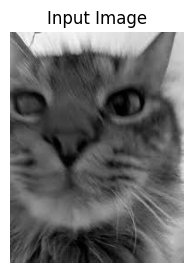

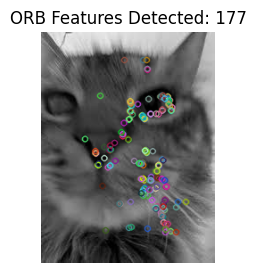

ORB Descriptor shape: (177, 32)


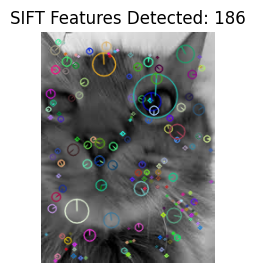

SIFT Descriptor shape: (186, 128)
SURF not supported(Patent restriction in OpenCV)
===== FEATURE EXTRACTION SUMMARY =====
ORB Features: 177
SIFT Features: 186


In [3]:
#feature extraction and feature detection
#SIFT = Scale Invarient Feature Transform
#ORB = oriented FAST and routed BRIEF
#SURF = speeded-up robust features
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Image loaded:", image_path)

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Display image
plt.figure(figsize=(3,3))
plt.imshow(gray, cmap = 'gray')
plt.title("Input Image")
plt.axis("off")
plt.show()

#create ORB detector
orb = cv2.ORB_create(nfeatures=500)

#Detect and compute
kp_orb, des_orb = orb.detectAndCompute(gray, None)

#Draw keypoints
orb_img = cv2.drawKeypoints(
    gray, kp_orb,None,
    flags= cv2.DrawMatchesFlags_DEFAULT
)

#Display
plt.figure(figsize=(3,3))
plt.imshow(orb_img, cmap='gray')
plt.title(f"ORB Features Detected: {len(kp_orb)}")
plt.axis("off")
plt.show()

print("ORB Descriptor shape:", des_orb.shape)

sift = cv2.SIFT_create()
kp_sift, des_sift = sift.detectAndCompute(gray, None)

#Draw keypoints
sift_img = cv2.drawKeypoints(
    gray, kp_sift, None,
    flags= cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
)

#Display
plt.figure(figsize=(3,3))
plt.imshow(sift_img, cmap='gray')
plt.title(f"SIFT Features Detected: {len(kp_sift)}")
plt.axis("off")
plt.show()

print("SIFT Descriptor shape:", des_sift.shape)

#Surf is patented and usually unvailable in Colab
try:
  surf = cv2.xfeatures2d.SURF_create(400)
  kp_surf, des_surf = surf.detectAndCompute(gray, None)

  surf_img = cv2.drawKeypoints(
      gray, kp_surf, None,
      flags= cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
  )
  plt.show(figsize=(3,3))
  plt.show(surf_img, cmap='gray')
  plt.title(f"SURF Features Detected: {len(kp_surf)}")
  plt.axis("off")
  plt.show

  print("SURF Descriptor Shape:", des_surf.shape)
except:
  print("SURF not supported(Patent restriction in OpenCV)")

print("===== FEATURE EXTRACTION SUMMARY =====")
print("ORB Features:", len(kp_orb))
print("SIFT Features:", len(kp_sift))


